# MNIST Image Recognition using Keras

### Importing necessary libraries

In [1]:
# Data Manipulation library
import numpy as np 
import pandas as pd

# Data visualisation libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

# Image Manipulation 
import cv2 as cv

# Evaluation and Splitting 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Deep Learning Libraries
import keras 
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, Lambda, MaxPooling2D
from keras.layers.normalization import BatchNormalization 
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.np_utils import to_categorical


Using TensorFlow backend.


In [2]:
# Uploading Data ( ONLY FOR COLLAB)
# from google.colab import files 
# files.upload() 

In [3]:
# Loading Data 
train_data = pd.read_csv('../input/digit-recognizer/train.csv')
test_data = pd.read_csv('../input/digit-recognizer/test.csv')

# Make original data copies 
train_og = train_data.copy() 
test_og = test_data.copy() 
print(train_data.shape, test_data.shape)

(42000, 785) (28000, 784)


In [4]:
# Sample of the data 
print(train_data.head())
print(test_data.head())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [5]:
# Extract only the features 
X = train_data.drop(['label'], axis = 1).values
y = train_data['label'].values
test_X = test_data.values

In [6]:
# Grayscale Normalization 
X = X / 255.0
test_X = test_X / 255.0

In [7]:
# Reshape the image data into 3 dimensions (height = 28pixels, width = 28px, 1)
# because 28 x 28 = 784 
X = X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)

### Encoding

In [8]:
# One hot encode the labels. There are 10 labels so we add 10 new dimensions
y = to_categorical(y)
print(y.shape)

(42000, 10)


In [9]:
# Train and validation splits 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=324)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(31500, 28, 28, 1) (31500, 10) (10500, 28, 28, 1) (10500, 10)


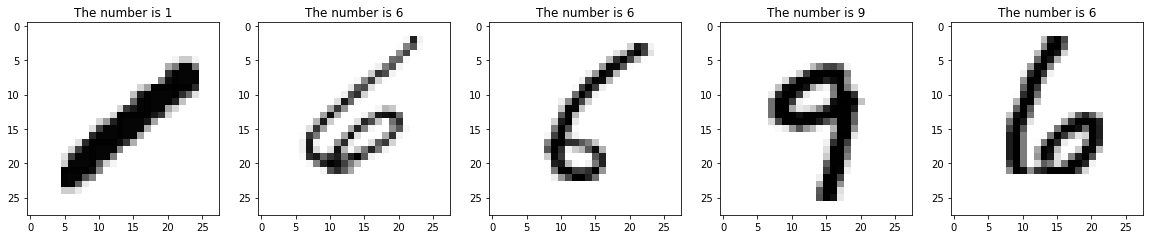

In [10]:
# Visulaisation of the data 
images = X_train.reshape(X_train.shape[0], 28, 28)

fig, axis = plt.subplots(1, 5, figsize=(20, 10))
for i, ax in enumerate(axis.flat):
    ax.imshow(images[i], cmap = 'binary')
    digit = y_train[i].argmax()   # finding the number where the array has a 1 which will be the max value
    ax.set(title = f"The number is {digit}")

## Building the CNN

In [11]:
# Important parameters
epochs = 50
batch_size = 64

In [12]:
# Building the CNN Model
model = Sequential() 
model.add(Conv2D(filters=64, kernel_size=(3,3),activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(Dropout(0.1))
model.add(MaxPooling2D(pool_size=(2,2))) # MaxPoolinglayer

#model.add(Conv2D(filters=128, kernel_size = (3,3), activation='relu'))
model.add(Dropout(0.1))
# model.add(MaxPooling2D(pool_size=(2,2)))    
# model.add(Conv2D(filters=256, kernel_size = (3,3), activation="relu"))
    
# model.add(MaxPooling2D(pool_size=(2,2)))
    
model.add(Flatten())
#model.add(BatchNormalization())
#model.add(Dense(512,activation="relu"))
    
model.add(Dense(10,activation="softmax"))
    
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        640       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 64)        36928     
_________________________________________________________________
dropout_1 (Dropout)          (None, 24, 24, 64)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)               

### Data Augmentation

In [13]:
# Using to prevent overfitting 

datagen = ImageDataGenerator(featurewise_center=False, 
                             samplewise_center=False, 
                             featurewise_std_normalization=False, 
                             samplewise_std_normalization=False, 
                             zca_whitening=False,
                             rotation_range=10, 
                             zoom_range=0.1,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             horizontal_flip=False,
                             vertical_flip=False)

#datagen.fit(X_train)
train_gen = datagen.flow(X_train, y_train, batch_size=batch_size)
test_gen = datagen.flow(X_val, y_val, batch_size=batch_size)

In [14]:
# Model training 
model.fit(X, y, batch_size=batch_size, validation_split=0.2, epochs=10)

Train on 33600 samples, validate on 8400 samples
Epoch 1/10
33600/33600 [==============================] - 90s 3ms/step - loss: 0.2169 - accuracy: 0.9353 - val_loss: 0.0811 - val_accuracy: 0.9750
Epoch 2/10
33600/33600 [==============================] - 90s 3ms/step - loss: 0.0651 - accuracy: 0.9810 - val_loss: 0.0717 - val_accuracy: 0.9780
Epoch 3/10
33600/33600 [==============================] - 90s 3ms/step - loss: 0.0462 - accuracy: 0.9859 - val_loss: 0.0546 - val_accuracy: 0.9838
Epoch 4/10
33600/33600 [==============================] - 91s 3ms/step - loss: 0.0342 - accuracy: 0.9891 - val_loss: 0.0527 - val_accuracy: 0.9829
Epoch 5/10
33600/33600 [==============================] - 99s 3ms/step - loss: 0.0264 - accuracy: 0.9913 - val_loss: 0.0565 - val_accuracy: 0.9825
Epoch 6/10
33600/33600 [==============================] - 91s 3ms/step - loss: 0.0222 - accuracy: 0.9928 - val_loss: 0.0532 - val_accuracy: 0.9848
Epoch 7/10
33600/33600 [==============================] - 90s 3ms/ste

In [15]:
# Prediction 
y_pred = model.predict(X_val) # Predict encoded label as integers between 0-9

Y_pred = np.argmax(y_pred, 1) # Decode Predicted labels
Y_test = np.argmax(y_val, 1) # Decode labels
acc_score = accuracy_score(y_true = Y_test, y_pred = Y_pred)
print(acc_score)

0.9964761904761905


In [16]:
# Printing Model Summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        640       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 64)        36928     
_________________________________________________________________
dropout_1 (Dropout)          (None, 24, 24, 64)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)               

In [17]:
results = model.predict_classes(test_X, verbose=1)
print(results)

# select the index with the maximum probability
results = pd.Series(results,name="Label")

## Output file 
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)
submission.to_csv("mnist.csv",index=False)

28000/28000 [==============================] - 17s 595us/step
[2 0 9 ... 3 9 2]


In [18]:
# Fit the model 
model_history = model.fit_generator(train_gen,
                                    epochs = epochs,
                                    steps_per_epoch = X_train.shape[0] // batch_size,
                                    validation_data = test_gen,
                                    validation_steps = X_val.shape[0] // batch_size)

Epoch 1/50
492/492 [==============================] - 91s 185ms/step - loss: 0.1879 - accuracy: 0.9451 - val_loss: 0.0203 - val_accuracy: 0.9652
Epoch 2/50
492/492 [==============================] - 90s 183ms/step - loss: 0.1142 - accuracy: 0.9661 - val_loss: 0.2442 - val_accuracy: 0.9717
Epoch 3/50
492/492 [==============================] - 92s 187ms/step - loss: 0.0892 - accuracy: 0.9730 - val_loss: 0.1980 - val_accuracy: 0.9760
Epoch 4/50
492/492 [==============================] - 91s 184ms/step - loss: 0.0795 - accuracy: 0.9755 - val_loss: 0.0203 - val_accuracy: 0.9784
Epoch 5/50
492/492 [==============================] - 91s 184ms/step - loss: 0.0686 - accuracy: 0.9796 - val_loss: 0.1422 - val_accuracy: 0.9814
Epoch 6/50
492/492 [==============================] - 90s 182ms/step - loss: 0.0693 - accuracy: 0.9788 - val_loss: 0.0401 - val_accuracy: 0.9845
Epoch 7/50
492/492 [==============================] - 91s 185ms/step - loss: 0.0668 - accuracy: 0.9799 - val_loss: 0.0439 - val_ac

In [19]:
# Prediction 
y_pred = model.predict(X_val) # Predict encoded label as integers between 0-9

Y_pred = np.argmax(y_pred, 1) # Decode Predicted labels
Y_test = np.argmax(y_val, 1) # Decode labels
acc_score = accuracy_score(y_true = Y_test, y_pred = Y_pred)
print(acc_score)

0.9928571428571429


In [20]:
results = model.predict_classes(test_X, verbose=1)
print(results)

# select the index with the maximum probability
results = pd.Series(results,name="Label")

## Output file 
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)
submission.to_csv("mnist2.csv",index=False)

28000/28000 [==============================] - 17s 603us/step
[2 0 9 ... 3 9 2]


## Low Parameter Model 

In [21]:
# Create model
model3 = Sequential()
model3.add(Conv2D(filters=8, kernel_size=(3,3),activation='relu', input_shape=(28,28,1)))
model3.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu'))
model3.add(Dropout(0.1))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Flatten())
model3.add(Dense(10, activation='softmax'))
# Compile and summarize
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 26, 26, 8)         80        
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 24, 24, 8)         584       
_________________________________________________________________
dropout_3 (Dropout)          (None, 24, 24, 8)         0         
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 12, 12, 8)         0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 1152)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                11530     
Total params: 12,194
Trainable params: 12,194
Non-trainable params: 0
__________________________________________________

In [22]:
# Train the model
x1 = train_og.drop(labels = ["label"],axis = 1) 
x1=x1.values.reshape(-1, 28, 28, 1)
x1 = x1 / 255.0
y1 = train_og['label']
model3.fit(x1, y1, epochs=30)

Epoch 1/30
42000/42000 [==============================] - 21s 508us/step - loss: 0.2795 - accuracy: 0.9180
Epoch 2/30
42000/42000 [==============================] - 22s 515us/step - loss: 0.0948 - accuracy: 0.9718
Epoch 3/30
42000/42000 [==============================] - 21s 499us/step - loss: 0.0731 - accuracy: 0.9779
Epoch 4/30
42000/42000 [==============================] - 21s 493us/step - loss: 0.0607 - accuracy: 0.9805
Epoch 5/30
42000/42000 [==============================] - 21s 493us/step - loss: 0.0515 - accuracy: 0.9842
Epoch 6/30
42000/42000 [==============================] - 21s 495us/step - loss: 0.0458 - accuracy: 0.9856
Epoch 7/30
42000/42000 [==============================] - 21s 489us/step - loss: 0.0412 - accuracy: 0.9870
Epoch 8/30
42000/42000 [==============================] - 21s 501us/step - loss: 0.0368 - accuracy: 0.9887
Epoch 9/30
42000/42000 [==============================] - 21s 494us/step - loss: 0.0319 - accuracy: 0.9899
Epoch 10/30
42000/42000 [============

In [23]:
# Prediction 
y_pred = model3.predict(X_val) # Predict encoded label as integers between 0-9

Y_pred = np.argmax(y_pred, 1) # Decode Predicted labels
Y_test = np.argmax(y_val, 1) # Decode labels
acc_score = accuracy_score(y_true = Y_test, y_pred = Y_pred)
print(acc_score)

0.9984761904761905


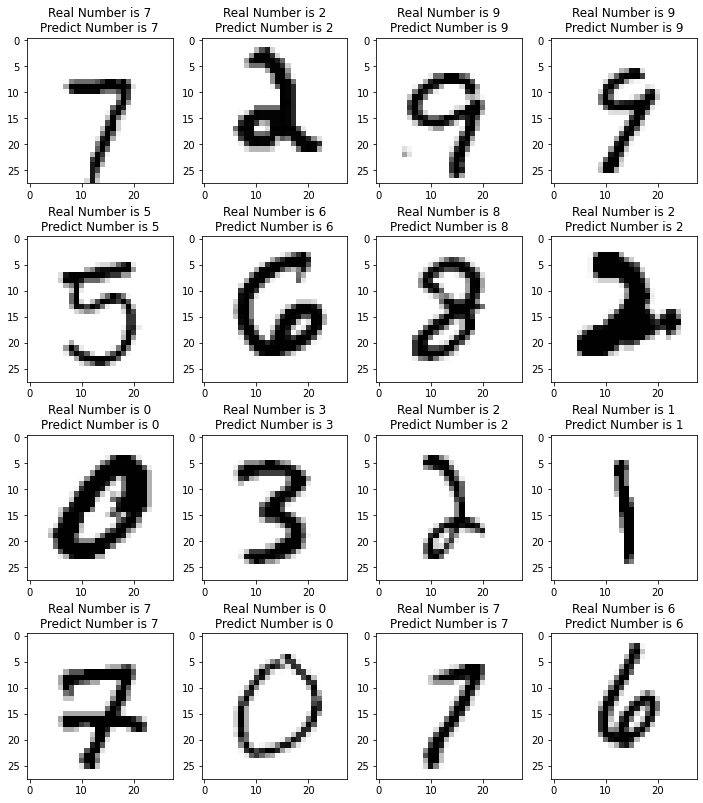

In [24]:
# Prediction 
y_pred = model3.predict(X_val)
X_val__ = X_val.reshape(X_val.shape[0], 28, 28)

fig, axis = plt.subplots(4, 4, figsize=(12, 14))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_val__[i], cmap='binary')
    ax.set(title = f"Real Number is {y_val[i].argmax()}\nPredict Number is {y_pred[i].argmax()}");

In [25]:
results = model3.predict_classes(test_X, verbose=1)
print(results)

# select the index with the maximum probability
results = pd.Series(results,name="Label")

## Output file 
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)
submission.to_csv("mnist3.csv",index=False)

28000/28000 [==============================] - 4s 160us/step
[2 0 9 ... 3 9 2]
